# Notebook 01 — Data Preprocessing
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

This notebook loads and cleans the two raw data files exported from **Tobii Pro Lab** after the eye-tracking session. The goal is to produce clean, well-structured files that all downstream notebooks can rely on.

**Inputs**
| File | Description |
|---|---|
| `data/raw/VisualTask with recording Metrics.tsv` | Pre-aggregated metrics per participant, per task, per AOI |
| `data/raw/VisualTask with recording Data export.tsv` | Raw gaze point stream (~30 MB, one row per sample) |

**Outputs**
| File | Description |
|---|---|
| `data/processed/metrics_clean.parquet` | Cleaned Metrics data |
| `data/processed/raw_gaze_clean.parquet` | Cleaned raw gaze data |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish between the **Metrics TSV** (pre-aggregated per AOI) and the **Data export TSV** (raw gaze stream), and explain when each is used
2. Identify and handle **Tobii sentinel values** — placeholder strings Tobii writes when data is unavailable (e.g. no fixations in an AOI)
3. Compute a **valid gaze sample rate** per participant and explain what constitutes acceptable data quality for eye-tracking studies
4. Explain why participant ID normalisation is a critical pre-processing step before any data join

---

## Background

### The Two Tobii Pro Lab Exports

**Metrics TSV** — Each row summarises one AOI during one trial for one participant. Key columns:

| Column | Cognitive meaning |
|---|---|
| `TOI` | Task name (e.g. `findDice`) |
| `AOI` | Region name (e.g. `answer`, `M1`) |
| `Total_duration_of_fixations` | Total ms the participant fixated on this AOI |
| `Number_of_fixations` | Count of fixation events in this AOI |
| `Time_to_first_fixation` | ms from trial start until first gaze entered this AOI |
| `Number_of_Visits` | How many times gaze entered and exited this AOI |
| `Average_pupil_diameter` | Mean pupil size while looking at this AOI |

**Data Export TSV** — One row per gaze sample (recorded at ~60–120 Hz). Contains raw gaze coordinates, eye movement classifications (`Fixation`, `Saccade`, `Unclassified`), pupil data, and binary `AOI hit` flags for every AOI at every moment.

### AOI Naming Convention
All task stimuli in this study use a consistent naming scheme:
- `answer` — the correct target region
- `M1`, `M2`, ... — distractor regions (wrong areas)

This allows the pipeline to treat all 8 tasks uniformly.

### Data Quality Threshold
A participant's recording is flagged if fewer than **70%** of their gaze samples have valid coordinates. Causes of invalid samples include blinking, head movement, or the participant looking off-screen.

---

## Discussion Questions

1. Why must participant IDs be normalised (lowercased, stripped) before any analysis? What real-world problem does this prevent?
2. A participant has a 65% valid gaze rate. Should you include or exclude them from analysis? What factors would influence your decision?
3. The Metrics file contains many null values for some AOIs. Why might a participant have *zero* fixations on a particular AOI during a task?
4. What is the difference between a **fixation** and a **saccade**? Why does this distinction matter for studying visual search?
5. This notebook saves data as Parquet instead of CSV. What advantages does Parquet provide for large datasets?

In [11]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from pathlib import Path

from src.config import (
    METRICS_TSV, DATAEXPORT_TSV,
    METRICS_CLEAN_PKL, RAWGAZE_CLEAN_PKL,
    MetricsCols, ExportCols, VALID_EYE_MOVEMENT_TYPES, TASKS
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)

## 1. Load Metrics TSV

In [12]:
metrics_raw = pd.read_csv(METRICS_TSV, sep='\t', low_memory=False)
print(f"Shape: {metrics_raw.shape}")
print(f"Columns ({len(metrics_raw.columns)}):")
metrics_raw.columns.tolist()

Shape: (630, 56)
Columns (56):


['Recording',
 'Participant',
 'Timeline',
 'TOI',
 'Interval',
 'Media',
 'AOI',
 'AOI_size',
 'Duration_of_interval',
 'Start_of_interval',
 'Last_key_press',
 'Total_duration_of_fixations',
 'Average_duration_of_fixations',
 'Minimum_duration_of_fixations',
 'Maximum_duration_of_fixations',
 'Number_of_fixations',
 'Time_to_first_fixation',
 'Duration_of_first_fixation',
 'Last_AOI_viewed',
 'AOI_at_interval_end',
 'Average_pupil_diameter',
 'Average_eye_openness',
 'Total_duration_of_whole_fixations',
 'Average_duration_of_whole_fixations',
 'Minimum_duration_of_whole_fixations',
 'Maximum_duration_of_whole_fixations',
 'Number_of_whole_fixations',
 'Time_to_first_whole_fixation',
 'Duration_of_first_whole_fixation',
 'Average_whole-fixation_pupil_diameter',
 'Average_whole-fixation_eye_openness',
 'Total_duration_of_Visit',
 'Average_duration_of_Visit',
 'Minimum_duration_of_Visit',
 'Maximum_duration_of_Visit',
 'Number_of_Visits',
 'Time_to_first_Visit',
 'Duration_of_first_Visi

In [13]:
# Null audit
null_pct = metrics_raw.isnull().mean().round(3) * 100
print("Null % per column:")
null_pct[null_pct > 0].sort_values(ascending=False)

Null % per column:


Time_to_first_mouse_click_and_release                  100.0
Time_from_first_fixation_to_mouse_click                100.0
Time_from_first_fixation_to_mouse_click_and_release    100.0
Time_to_first_mouse_click                               99.7
AOI_at_interval_end                                     79.0
                                                       ...  
Minimum_duration_of_Glances                             53.3
Maximum_duration_of_Visit                               53.3
Duration_of_first_Visit                                 53.3
Last_key_press                                          48.3
Last_AOI_viewed                                          4.8
Length: 35, dtype: float64

## 2. Clean Metrics TSV

In [14]:
metrics = metrics_raw.copy()

# Standardize participant ID
metrics[MetricsCols.PARTICIPANT] = (
    metrics[MetricsCols.PARTICIPANT]
    .astype(str).str.strip().str.lower()
)

# Keep only rows with both TOI and AOI populated (drop aggregate rows)
before = len(metrics)
metrics = metrics[
    metrics[MetricsCols.TOI].notna() &
    metrics[MetricsCols.AOI].notna()
].copy()
print(f"Rows after filtering to TOI+AOI rows: {len(metrics)} (removed {before - len(metrics)})")

# Replace Tobii sentinel dashes with NaN
metrics.replace('-', np.nan, inplace=True)
metrics.replace('- ', np.nan, inplace=True)

# Cast numeric columns
numeric_cols = metrics.columns.difference([
    MetricsCols.RECORDING, MetricsCols.PARTICIPANT, MetricsCols.TIMELINE,
    MetricsCols.TOI, MetricsCols.INTERVAL, MetricsCols.MEDIA, MetricsCols.AOI,
    MetricsCols.LAST_KEY_PRESS, MetricsCols.LAST_AOI_VIEWED, MetricsCols.AOI_AT_INTERVAL_END
])
for col in numeric_cols:
    metrics[col] = pd.to_numeric(metrics[col], errors='coerce')

# Confirm tasks present in Media column
print("\nMedia values found:")
print(metrics[MetricsCols.MEDIA].value_counts())

print("\nParticipants found:")
print(metrics[MetricsCols.PARTICIPANT].value_counts())

Rows after filtering to TOI+AOI rows: 630 (removed 0)

Media values found:
Media
EndTq,findDice,findYummy,frog,frogInBathroom,headphoneInBathroom,PracticeIns,spotNeedleInst,StartInst,Text (1),whoCheats,whoThief    252
frog                                                                                                                                  64
EndTq,findDice,findYummy,frog,frogInBathroom,headphoneInBathroom,PracticeIns,spotNeedleInst,StartInst,Text (1)                        63
frogInBathroom                                                                                                                        44
spotNeedleInst                                                                                                                        40
findYummy                                                                                                                             36
headphoneInBathroom                                                                              

## 3. Load Data Export TSV

In [15]:
# This file is ~31 MB — loading may take a moment
export_raw = pd.read_csv(DATAEXPORT_TSV, sep='\t', low_memory=False)
print(f"Shape: {export_raw.shape}")
export_raw.head(3)

Shape: (52774, 269)


,Recording timestamp,Computer timestamp,Sensor,Project name,Export date,Participant name,Recording name,Recording date,Recording date UTC,Recording start time,Recording start time UTC,Recording duration,Timeline name,Recording Fixation filter name,Recording software version,Recording resolution height,Recording resolution width,Recording monitor latency,Average calibration accuracy (mm),Average calibration precision SD (mm),Average calibration precision RMS (mm),Average calibration accuracy (degrees),Average calibration precision SD (degrees),Average calibration precision RMS (degrees),Average calibration accuracy (pixels),...,AOI hit [whoCheats - M8],AOI hit [whoThief - M8],AOI hit [frogInBathroom - M9],AOI hit [frog - M9],AOI hit [spotNeedleInst - M9],AOI hit [whoCheats - M9],AOI hit [whoThief - M9],AOI hit [frogInBathroom - M10],AOI hit [frog - M10],AOI hit [whoThief - M10],AOI hit [frog - M11],AOI hit [frog - M12],AOI hit [frog - M13],AOI hit [frog - M14],AOI hit [frog - M15],Client area position X (DACSpx),Client area position Y (DACSpx),Viewport position X,Viewport position Y,Viewport width,Viewport height,Full page width,Full page height,Mouse position X,Mouse position Y
0,0,9660891715789,NaN,VisualTask with recording,4/10/2026,test1,Recording1,4/7/2026,4/7/2026,08:43:31.073,00:43:31.073,143893,Timeline1,Tobii I-VT (Fixation),24.21.435,1080,1920,10.0,2.4,7.5,5.7,0.21,0.65,0.49,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120447,9660891836236,Eye Tracker,VisualTask with recording,4/10/2026,test1,Recording1,4/7/2026,4/7/2026,08:43:31.073,00:43:31.073,143893,Timeline1,Tobii I-VT (Fixation),24.21.435,1080,1920,10.0,2.4,7.5,5.7,0.21,0.65,0.49,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,137112,9660891852901,Eye Tracker,VisualTask with recording,4/10/2026,test1,Recording1,4/7/2026,4/7/2026,08:43:31.073,00:43:31.073,143893,Timeline1,Tobii I-VT (Fixation),24.21.435,1080,1920,10.0,2.4,7.5,5.7,0.21,0.65,0.49,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Clean Data Export TSV

In [16]:
gaze = export_raw.copy()

# Standardize participant ID
gaze[ExportCols.PARTICIPANT_NAME] = (
    gaze[ExportCols.PARTICIPANT_NAME]
    .astype(str).str.strip().str.lower()
)

# Replace Tobii string sentinels
sentinel_cols = [
    ExportCols.GAZE_X, ExportCols.GAZE_Y,
    ExportCols.FIXATION_X, ExportCols.FIXATION_Y,
    ExportCols.PUPIL_LEFT, ExportCols.PUPIL_RIGHT, ExportCols.PUPIL_FILTERED,
    ExportCols.EYE_OPEN_LEFT, ExportCols.EYE_OPEN_RIGHT, ExportCols.EYE_OPEN_FILT,
]
gaze[sentinel_cols] = gaze[sentinel_cols].replace('-', np.nan).replace('- ', np.nan)
for col in sentinel_cols:
    gaze[col] = pd.to_numeric(gaze[col], errors='coerce')

# Cast eye movement duration
gaze[ExportCols.EYE_MOVEMENT_DURATION] = pd.to_numeric(
    gaze[ExportCols.EYE_MOVEMENT_DURATION], errors='coerce'
)

# Validate Eye movement type
invalid_types = gaze[ExportCols.EYE_MOVEMENT_TYPE].dropna()
invalid_types = invalid_types[~invalid_types.isin(VALID_EYE_MOVEMENT_TYPES)]
print(f"Unexpected Eye movement type values: {invalid_types.unique()[:10]}")

# Cast AOI hit columns to int8
aoi_hit_cols = [c for c in gaze.columns if c.startswith(ExportCols.AOI_HIT_PREFIX)]
print(f"\nAOI hit columns found: {len(aoi_hit_cols)}")
gaze[aoi_hit_cols] = gaze[aoi_hit_cols].replace('-', 0).fillna(0).astype('int8')

Unexpected Eye movement type values: ['EyesNotFound']

AOI hit columns found: 84


## 5. Data Quality: Per-Participant Valid Gaze Rate

In [17]:
# Valid = row has a valid Gaze point X (not NaN)
gaze['_valid_sample'] = gaze[ExportCols.GAZE_X].notna().astype(int)

quality = (
    gaze.groupby(ExportCols.PARTICIPANT_NAME)['_valid_sample']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'valid_samples', 'count': 'total_samples'})
)
quality['valid_rate'] = quality['valid_samples'] / quality['total_samples']
quality = quality.sort_values('valid_rate')

flagged = quality[quality['valid_rate'] < 0.70]
print(f"Participants below 70% valid gaze: {len(flagged)}")
display(quality)

Participants below 70% valid gaze: 0


/tmp/ipykernel_228863/3365901472.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gaze['_valid_sample'] = gaze[ExportCols.GAZE_X].notna().astype(int)


,valid_samples,total_samples,valid_rate
Participant name,,,
p002,11302,15289,0.739224
test2,5721,7422,0.770816
p001,16788,21022,0.798592
test1,8307,9041,0.918814


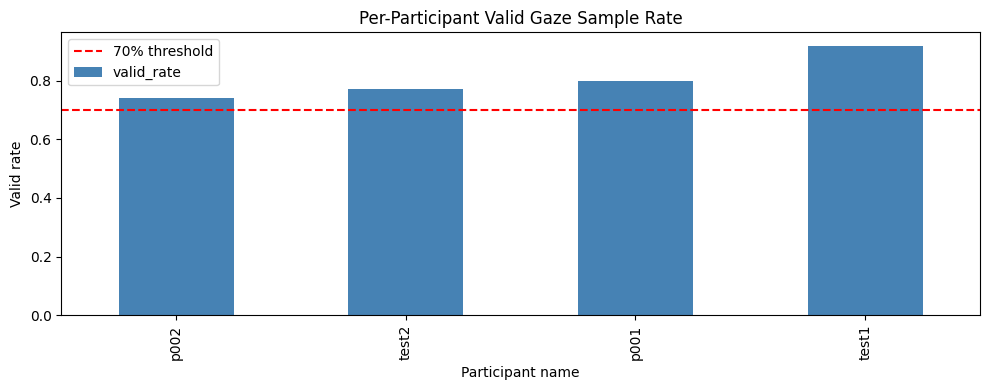

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
quality['valid_rate'].sort_values().plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.70, color='red', linestyle='--', label='70% threshold')
ax.set_title('Per-Participant Valid Gaze Sample Rate')
ax.set_ylabel('Valid rate')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/01_gaze_quality.png', dpi=150)
plt.show()

## 6. Participant ID Alignment Check

In [19]:
metrics_participants = set(metrics[MetricsCols.PARTICIPANT].unique())
gaze_participants    = set(gaze[ExportCols.PARTICIPANT_NAME].unique())

only_in_metrics = metrics_participants - gaze_participants
only_in_gaze    = gaze_participants - metrics_participants

print(f"Participants in Metrics only: {only_in_metrics}")
print(f"Participants in Data export only: {only_in_gaze}")
print(f"Shared participants: {len(metrics_participants & gaze_participants)}")

Participants in Metrics only: set()
Participants in Data export only: set()
Shared participants: 4


## 7. Save to Parquet

In [20]:
metrics.drop(columns=['_valid_sample'], errors='ignore').to_parquet(METRICS_CLEAN_PKL, index=False)
gaze.drop(columns=['_valid_sample'], errors='ignore').to_parquet(RAWGAZE_CLEAN_PKL, index=False)

print(f"Saved: {METRICS_CLEAN_PKL}")
print(f"  Shape: {metrics.shape}")
print(f"Saved: {RAWGAZE_CLEAN_PKL}")
print(f"  Shape: {gaze.shape}")

Saved: /home/wlsoo/WID2003/data/processed/metrics_clean.parquet
  Shape: (630, 56)
Saved: /home/wlsoo/WID2003/data/processed/raw_gaze_clean.parquet
  Shape: (52774, 270)
